# Part 1

For part 1, I will be implementing an MDP agent on Frozenlake with slippery = True using the value iteration algorithm.

## Description of Frozenlake

States in Frozen lake can be represented as a grid of values, with each coordinate containing a start, ice, hole, or goal. However, for computation, the state space is flattened into a vector.

Let the state space be $S$

$\mathbf{S}=\{S_0, S_1, ..., S_n\}$

$S_i\in \{St,I,H,G\}$

The action space of the agent permits movement in one of four directions from a given tile. Let $A$ be the action space.

$A\in \{U,D,L,R\}$

The reward structure of FL is cutomizable but by default is binary. Either positive $1$ if the goal is reached or 0. It can be modified to have greater penalty for falling into the pits.

The discount factor is represented by the $\gamma$ in the Bellman equation, which controls for how much future moves affects present movement considerations.


In [84]:
!pip install -r https://raw.githubusercontent.com/huggingface/deep-rl-class/main/notebooks/unit2/requirements-unit2.txt

  Using cached pickle5-0.0.11.tar.gz (132 kB)
  Preparing metadata (setup.py) ... done
  Using cached PyYAML-6.0.tar.gz (124 kB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [85]:
!sudo apt-get update
!sudo apt-get install -y python3-opengl
!apt install ffmpeg xvfb
!pip3 install pyvirtualdisplay

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,967 kB]
Fetched 13.0 MB in 3s (3,742 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources

In [86]:
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import gymnasium as gym

env = gym.make(
    'FrozenLake-v1',
    render_mode="rgb_array",
    desc=None,
    map_name="4x4",
    is_slippery=True
)

In [87]:
from pyvirtualdisplay import Display
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

vdisplay = Display(visible=False, size=(400, 400))
vdisplay.start()

In [88]:
seed = 42
env.action_space.seed(seed)

42

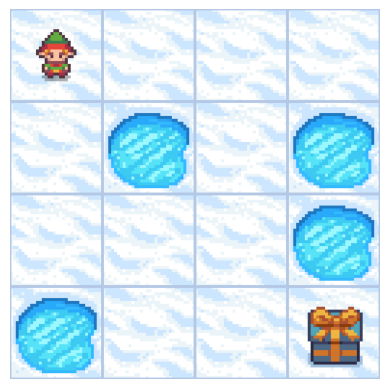

In [89]:
obs, _ = env.reset(seed=seed)
frame = env.render()

plt.imshow(frame)
plt.axis('off')
plt.show()

In [90]:
import numpy as np

def bellman(value_table, s, gamma):
  return [sum([prob*(r + gamma * value_table[s_])
                             for prob, s_, r, _ in env.unwrapped.P[s][a]])
                                   for a in range(env.action_space.n)]

def propagate_V(env, num_runs, gamma):
  value_table = np.zeros(env.observation_space.n)
  value_function_history = [value_table.copy()]

  print(value_table.shape)

  for i in range(num_runs):
    updated_value_table = np.copy(value_table)
    for s in range(env.observation_space.n):
      value_table[s] = max(bellman(updated_value_table, s, gamma))

    value_function_history.append(value_table.copy())

    # print(f"Iteration {i+1}:")
    # print(value_table.reshape((4,4)))

  return value_table, value_function_history


value_function, value_history = propagate_V(env, 300, 1.0)

(16,)


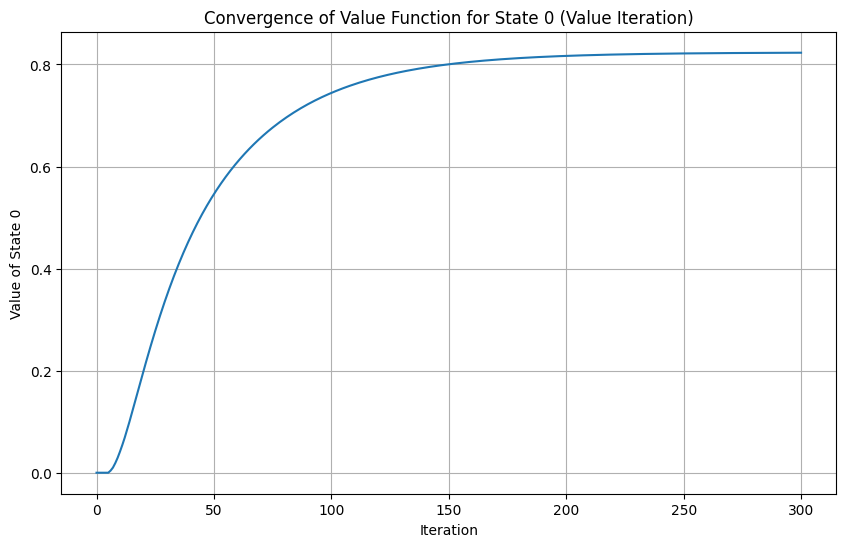

In [91]:
import matplotlib.pyplot as plt

state_0_values = [v_func[0] for v_func in value_history]

plt.figure(figsize=(10, 6))
plt.plot(state_0_values)
plt.xlabel("Iteration")
plt.ylabel("Value of State 0")
plt.title("Convergence of Value Function for State 0 (Value Iteration)")
plt.grid(True)
plt.show()

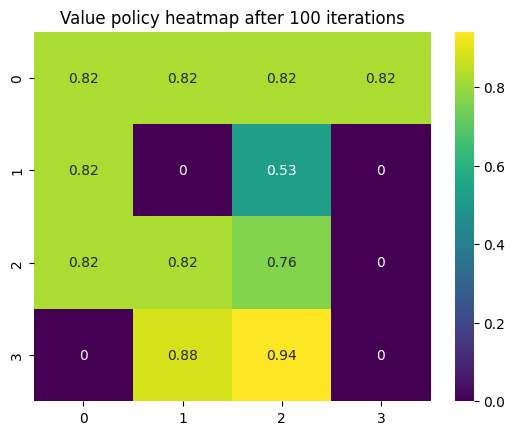

In [92]:
import seaborn as sns

data = value_function.reshape(4,4)
sns.heatmap(data, annot=True, cmap='viridis')
plt.title("Value policy heatmap after 100 iterations")
plt.show()

(16,)


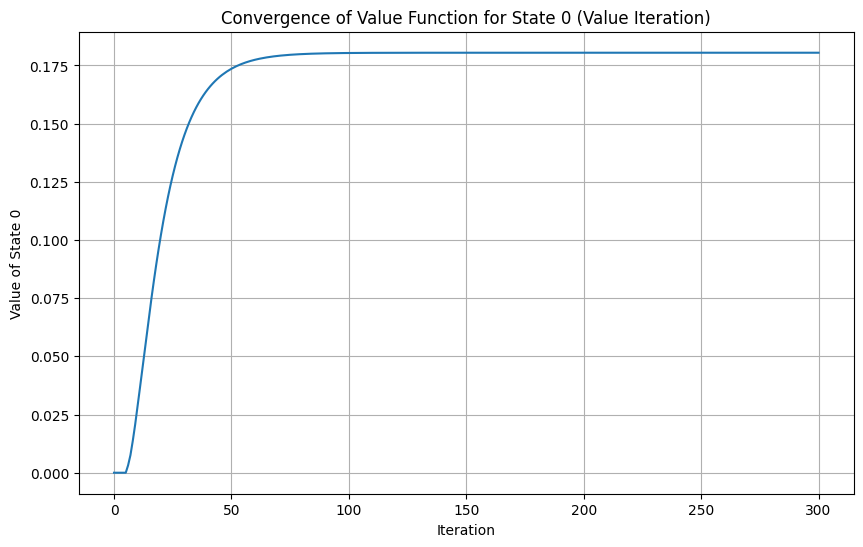

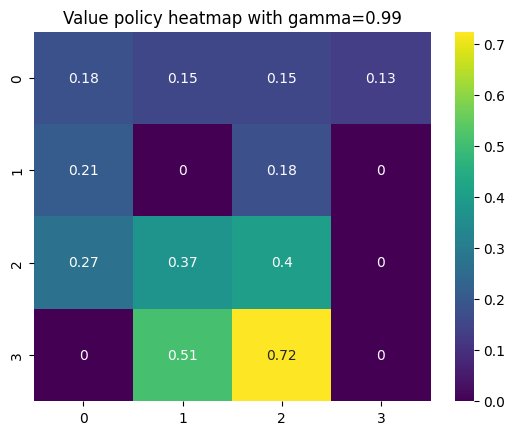

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

value_function, value_history = propagate_V(env, 300, 0.95)

state_0_values = [v_func[0] for v_func in value_history]

plt.figure(figsize=(10, 6))
plt.plot(state_0_values)
plt.xlabel("Iteration")
plt.ylabel("Value of State 0")
plt.title("Convergence of Value Function for State 0 (Value Iteration)")
plt.grid(True)
plt.show()

data = value_function.reshape(4,4)
sns.heatmap(data, annot=True, cmap='viridis')
plt.title("Value policy heatmap with gamma=0.99")
plt.show()

(16,)


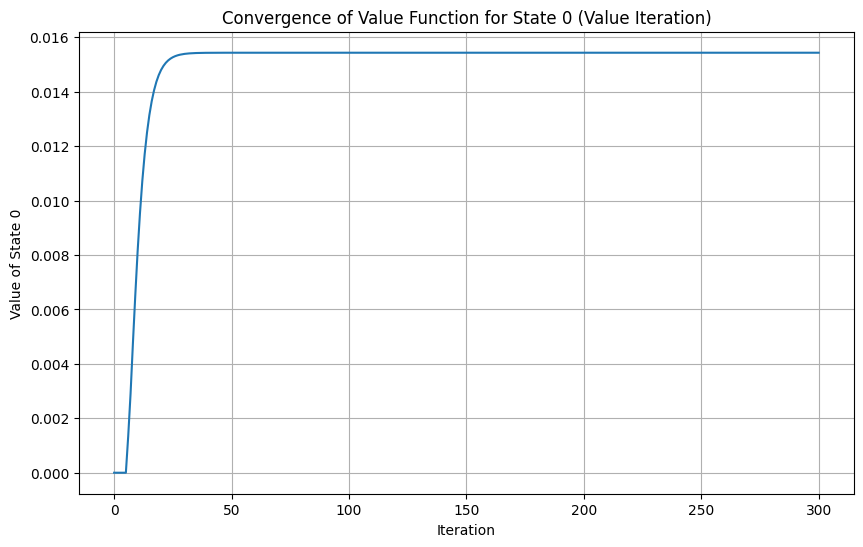

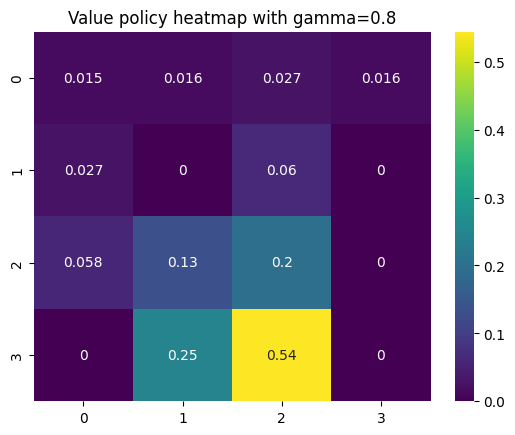

In [97]:
value_function, value_history = propagate_V(env, 300, 0.8)

state_0_values = [v_func[0] for v_func in value_history]

plt.figure(figsize=(10, 6))
plt.plot(state_0_values)
plt.xlabel("Iteration")
plt.ylabel("Value of State 0")
plt.title("Convergence of Value Function for State 0 (Value Iteration)")
plt.grid(True)
plt.show()

data = value_function.reshape(4,4)
sns.heatmap(data, annot=True, cmap='viridis')
plt.title("Value policy heatmap with gamma=0.8")
plt.show()

In the original value iteration, the probabilities for most of the correct states are uniform. As shown here, when $\gamma$ is lowered from 1, the agent becomes less sure of early paths, as future choices are weighted higher. This effect is more exaggerated the lower the discount term is.

# Part 2

For the mini-research task, I will be examining tree neural networks. Tree neural networks are hybrid decision trees and neural networks that permit a layer of explainability on top of neural classifiers and regressors. Most often they seem to be deployed on image classification tasks, and the hierarchy often follows the taxonomy of image types [1]. When deployed like this, the approach is a form of neuro-symbolic computing:

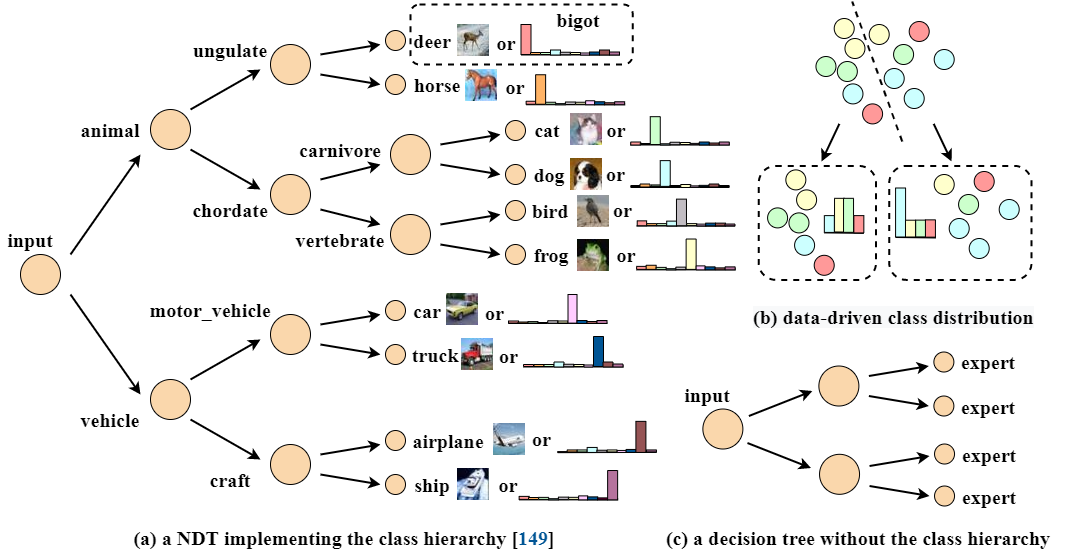 (image source: [2])


[1] https://arxiv.org/pdf/1802.05800

[2] https://github.com/zju-vipa/awesome-neural-trees

Most modern tree-CNNs seem to have means of implicitly creating new classes to optimize learning, similar to a classical ML decision trees. Because I am interested in the explainability angle, I will try to implement a simpler, deliberately coded one resembling the figure in the above text block. I will use a subset of CIFAR, specifically selecting the cat, dog, bird, and frog classes.

Although the papers are slightly older, I think this does have direct relevence to modern deep learning, as it tackles explainability, as well as mixture-of-experts routing approaches, which are important, particularly for LLM safety and localization.

In [1]:
from datasets import load_dataset
"""
This code is AI generated
"""

print("Loading CIFAR-10 dataset...")
dataset = load_dataset('cifar10')
print("CIFAR-10 dataset loaded.")

target_classes = {'cat', 'dog', 'bird', 'frog'}
class_labels = dataset['train'].features['label'].names
print(f"Original CIFAR-10 class labels: {class_labels}")

target_class_ids = [idx for idx, label in enumerate(class_labels) if label in target_classes]
print(f"Target classes: {target_classes} with IDs: {target_class_ids}")

def filter_classes(example):
    return example['label'] in target_class_ids

filtered_dataset = dataset.filter(filter_classes)

print(f"Dataset filtered. New training set size: {len(filtered_dataset['train'])}")
print(f"New test set size: {len(filtered_dataset['test'])}")

Loading CIFAR-10 dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

CIFAR-10 dataset loaded.
Original CIFAR-10 class labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Target classes: {'frog', 'bird', 'cat', 'dog'} with IDs: [2, 3, 5, 6]


Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset filtered. New training set size: 20000
New test set size: 4000


In [2]:
from torch import nn
import torch

class CNN_head(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequence = torch.nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.Flatten(),

            nn.Linear(3200, 500) # 500 dimensional feature space
        )
    def forward(self, x):
      logits = self.sequence(x)

      return logits


In [3]:
class tree_classifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.feature_head = CNN_head()

    self.gate = nn.Linear(500, 4)

    self.mammal_head = nn.Linear(500, 2)
    self.non_mammal_head = nn.Linear(500, 2)

  def forward(self, x):
    feature_space = self.feature_head(x)

    gate_probs = nn.ReLU()(self.gate(feature_space))
    mammal_probs = nn.ReLU()(self.mammal_head(feature_space))
    non_mammal_probs = nn.ReLU()(self.non_mammal_head(feature_space))

    p_cat  = gate_probs[:, 0] * mammal_probs[:, 0]
    p_dog  = gate_probs[:, 0] * mammal_probs[:, 1]
    p_bird = (1 - gate_probs[:, 0]) * non_mammal_probs[:, 0]
    p_frog = (1 - gate_probs[:, 0]) * non_mammal_probs[:, 1]

    return torch.stack([p_cat, p_dog, p_bird, p_frog], dim=1)

The model is able to backpropagate because it calculates conditional probability implicitly. The resulting output logits is given by the vector:

$\begin{bmatrix} P[cat]\cdot P[mammal]\\P[dog]\cdot P[mammal]\\P[bird]\cdot P[nonmammal]\\P[frog]\cdot P[nonmammal]\end{bmatrix}$

In [5]:
# Sanity check for CNN_head

dummy_input = torch.randn(1, 3, 32, 32)

model = tree_classifier()

output = model(dummy_input)

print(output.shape)

torch.Size([1, 4])


In [6]:
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.data = X.to(torch.float32)
        self.labels = y.to(torch.long)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def plot_metric(to_plot, labels, file_name, title="", ylabel="Value"):
  plt.figure()

  for values, label in zip(to_plot, labels):
      plt.plot(values, label=label)

  plt.xlabel("Epoch")
  plt.ylabel(ylabel)
  plt.title(title)
  plt.legend()
  #plt.savefig(file_name)
  plt.show()
  plt.close()


def evaluate(model, dataloader, batch_size=1000, device=torch.device("cuda")):
  model.eval()
  model.to(device)

  criterion = torch.nn.CrossEntropyLoss()

  correct = 0
  total = 0
  total_loss = 0.0

  with torch.no_grad():
    for (X_batch, Y_batch) in dataloader:
      X_batch = X_batch.to(device)
      Y_batch = Y_batch.to(device).long()

      logits = model(X_batch)
      loss = criterion(logits, Y_batch)

      preds = torch.argmax(logits, dim=1)

      correct += (preds == Y_batch).sum().item()
      total += Y_batch.size(0)
      total_loss += loss.item() * Y_batch.size(0)

  avg_loss = total_loss / total
  accuracy = correct / total

  return accuracy, avg_loss

In [7]:
def train_loop(model: torch.nn.Module, training_set, testing_set, batch_size=32, epochs=10, device=torch.device("cuda")):
  train_dataloader = DataLoader(training_set, batch_size=batch_size, shuffle=True)
  test_dataloader = DataLoader(testing_set, batch_size=batch_size, shuffle=True)

  model.to(device)

  optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.001)
  criterion = torch.nn.CrossEntropyLoss()

  train_losses = []
  test_losses = []

  train_accuracies = []
  test_accuracies = []

  for epoch in range(epochs):
    total_loss = 0.0
    print("Epoch:", epoch)
    for batch_i, (X_batch, Y_batch) in enumerate(train_dataloader):

      model.train()
      X_batch = X_batch.to(device)
      Y_batch = Y_batch.to(device)

      optimizer.zero_grad()

      Y_pred = model(X_batch)
      loss = criterion(Y_pred, Y_batch)
      loss.backward()

      torch.nn.utils.clip_grad_value_(model.parameters(), clip_value=0.1)

      optimizer.step()

      total_loss += loss.item()
      # print("batch accuracy:", evaluate(model, test_dataloader, device))

    train_acc, train_loss = evaluate(model, train_dataloader, device=device)
    test_acc, test_loss = evaluate(model, test_dataloader, device=device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print("epoch loss:", total_loss)
    print("train acc:", train_acc)
    print("test acc:", test_acc)

  plot_metric([train_losses, test_losses],["train losses", "test losses"], "train_test_losses.png", title="losses vs epoch")
  plot_metric([train_accuracies, test_accuracies],["train accuracy", "test accuracy"], "train_test_accuracy.png", title="accuracy vs epoch")

In [8]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

original_label_to_new_label = {
    3: 0, # cat
    5: 1, # dog
    2: 2, # bird
    6: 3  # frog
}

def apply_transforms_and_remap_labels(example):
    example['img'] = transform(example['img'])
    example['label'] = original_label_to_new_label[example['label']]
    return example

processed_train_dataset = filtered_dataset['train'].map(apply_transforms_and_remap_labels)
processed_test_dataset = filtered_dataset['test'].map(apply_transforms_and_remap_labels)

processed_train_dataset.set_format(type="torch", columns=['img', 'label'])
processed_test_dataset.set_format(type="torch", columns=['img', 'label'])

X_train = torch.stack(list(processed_train_dataset['img']))
y_train = torch.tensor(list(processed_train_dataset['label']), dtype=torch.long) # Specify dtype for labels

X_test = torch.stack(list(processed_test_dataset['img']))
y_test = torch.tensor(list(processed_test_dataset['label']), dtype=torch.long) # Specify dtype for labels

training_data = CustomDataset(X_train, y_train)
testing_data = CustomDataset(X_test, y_test)

print(f"Training data shape: {training_data.data.shape}, labels shape: {training_data.labels.shape}")
print(f"Testing data shape: {testing_data.data.shape}, labels shape: {testing_data.labels.shape}")

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Training data shape: torch.Size([20000, 3, 32, 32]), labels shape: torch.Size([20000])
Testing data shape: torch.Size([4000, 3, 32, 32]), labels shape: torch.Size([4000])


Using device: cuda
Starting model training...
Epoch: 0
epoch loss: 357.31099063158035
train acc: 0.57845
test acc: 0.56575
Epoch: 1
epoch loss: 295.81246465444565
train acc: 0.6602
test acc: 0.6275
Epoch: 2
epoch loss: 270.69072288274765
train acc: 0.6762
test acc: 0.6315
Epoch: 3
epoch loss: 252.8564840555191
train acc: 0.6961
test acc: 0.64175
Epoch: 4
epoch loss: 242.4723253250122
train acc: 0.72095
test acc: 0.6475
Epoch: 5
epoch loss: 228.9769807457924
train acc: 0.7466
test acc: 0.66075
Epoch: 6
epoch loss: 216.04015722870827
train acc: 0.75885
test acc: 0.66175
Epoch: 7
epoch loss: 205.4937702715397
train acc: 0.75145
test acc: 0.6485


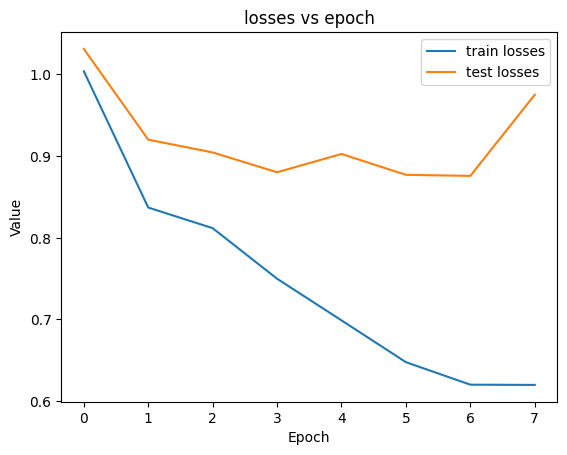

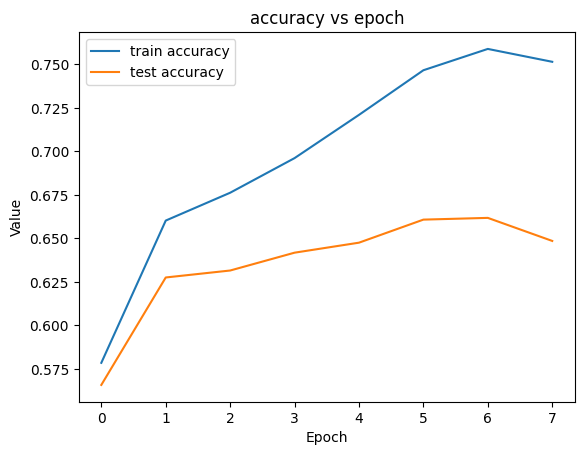

Model training complete.


In [12]:
model = tree_classifier()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Starting model training...")
train_loop(model, training_data, testing_data, batch_size=64, epochs=8, device=device)
print("Model training complete.")

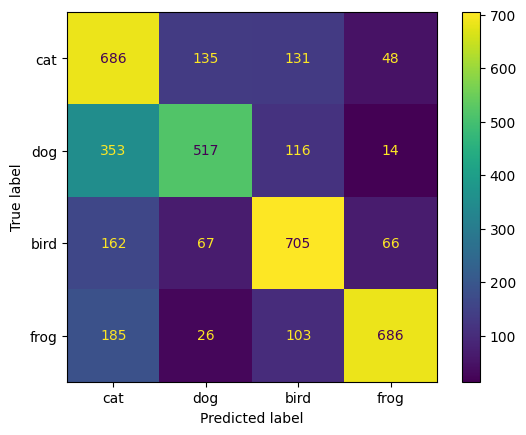

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

with torch.no_grad():
  Y_pred = model(X_test.to(device))

  Y_pred = torch.argmax(Y_pred, dim=1).to('cpu').numpy()

display_labels = ["cat", "dog", "bird", "frog"]
cm = confusion_matrix(y_test, Y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()
plt.show()


For reference, I'm going to train a baseline model as well.

Using device: cuda
Starting model training...
Epoch: 0
epoch loss: 360.1797903776169
train acc: 0.58215
test acc: 0.5625
Epoch: 1
epoch loss: 323.7947486639023
train acc: 0.5869
test acc: 0.56075
Epoch: 2
epoch loss: 305.7840674519539
train acc: 0.65155
test acc: 0.618
Epoch: 3
epoch loss: 291.9408664703369
train acc: 0.6721
test acc: 0.62075
Epoch: 4
epoch loss: 279.126617372036
train acc: 0.68795
test acc: 0.62375
Epoch: 5
epoch loss: 266.50092232227325
train acc: 0.71635
test acc: 0.63825
Epoch: 6
epoch loss: 250.86737713217735
train acc: 0.7776
test acc: 0.65675
Epoch: 7
epoch loss: 239.0364533662796
train acc: 0.77745
test acc: 0.65075


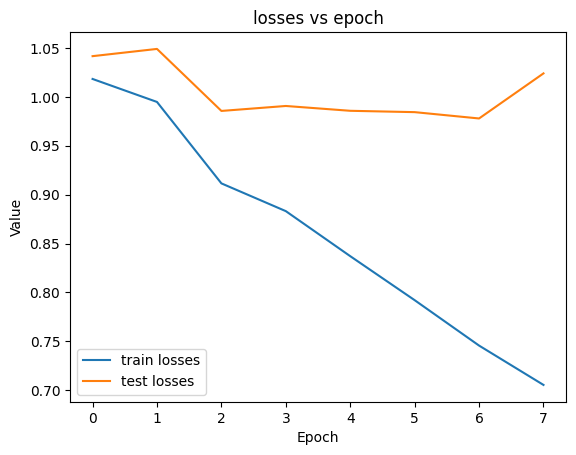

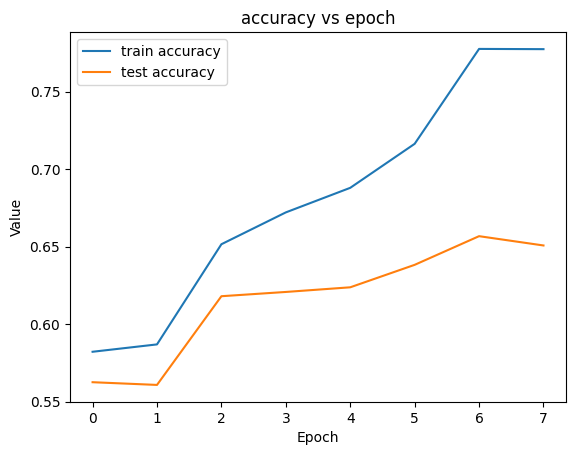

Model training complete.


In [23]:
class vanilla_cnn(tree_classifier):
  def __init__(self):
    super().__init__()

    self.linear = nn.Linear(500, 500)

  def forward(self, x):
    feature_space = self.feature_head(x)
    linear_logits = torch.nn.ReLU()(self.linear(feature_space))

    gate_probs = nn.ReLU()(self.gate(linear_logits))

    return gate_probs



model = vanilla_cnn()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Starting model training...")
train_loop(model, training_data, testing_data, batch_size=64, epochs=8, device=device)
print("Model training complete.")

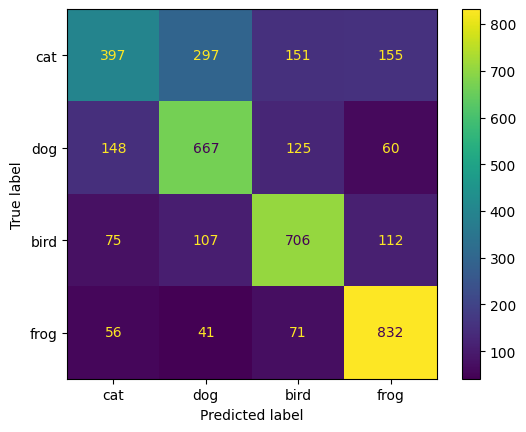

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

with torch.no_grad():
  Y_pred = model(X_test.to(device))

  Y_pred = torch.argmax(Y_pred, dim=1).to('cpu').numpy()

display_labels = ["cat", "dog", "bird", "frog"]
cm = confusion_matrix(y_test, Y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()
plt.show()

The performance distinguishing between the four classes is quite strong on both, but the tree-based model seems to have an advantage in precision and recall for each class. I'd imagine if we calculated F1 scores, the tree-based classifier would perform better. Likewise, it achieves the goal of being more explainable while also performing slightly better.


While the method will work for type classification for data that is easily decomposable into different hierarchical classes, for data that isn't, it may be worth following an approach that optimizes tree node types probablisitically or just uses a conventional continuous network. Further, excessively large or complex trees may run the risk of introducing too much CPU operation overhead, making them slower to train on GPUs. This hearkens to one of the advantages of transformers over recurrence.

Additionally, I specifically chose to investigate tree NNs because I am interested in NLP compositional semantics rather than decomposition, but I did not realize how different the approaches would be. If we were say trying to implement a parse-tree-based encoder, we may not have access to anything as elegent as the conditional probability calculations here.

Further work on the image classifier specifically could involve implementing the full CIFAR-10 hierarchy. I could also investigate approaches to automated tree expansion.